In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)

PROCESSED = Path("../../data/processed")
print("Loading data...")

prices = pd.read_parquet(PROCESSED / "prices.parquet")
prices["datetime"] = pd.to_datetime(prices["datetime"], utc=True)
print(f"Prices: {prices.shape[0]:,} points, {prices['token_id'].nunique()} tokens")

markets = pd.read_parquet(PROCESSED / "markets.parquet")
print(f"Markets: {markets.shape[0]:,} rows")

trades = pd.read_parquet(PROCESSED / "trades.parquet")
trades["datetime"] = pd.to_datetime(trades["datetime"], utc=True)
print(f"Trades: {trades.shape[0]:,} trades, {trades['conditionId'].nunique()} markets")

token_meta = markets[["token_id_yes", "conditionId", "question", "volumeNum", "negRisk", "_event_title"]].copy()
token_meta = token_meta.rename(columns={"token_id_yes": "token_id"}).dropna(subset=["token_id"])

if "_tags_flat" in markets.columns:
    token_meta = token_meta.merge(
        markets[["token_id_yes", "_tags_flat"]].rename(columns={"token_id_yes": "token_id"}).dropna(subset=["token_id"]),
        on="token_id", how="left"
    )

    token_meta["category"] = token_meta["_tags_flat"].apply(
        lambda x: x.split(",")[0] if isinstance(x, str) and x else "Unknown"
    )
else:
    token_meta["category"] = "Unknown"

prices = prices.merge(token_meta[["token_id", "question", "volumeNum", "category", "conditionId"]],
                       on="token_id", how="left")
print(f"\nTokens with metadata: {prices['question'].notna().sum():,} / {len(prices):,}")
print(f"Categories: {prices['category'].value_counts().head(10).to_dict()}")

Loading data...
Prices: 198,493 points, 100 tokens
Markets: 50,609 rows
Trades: 154,819 trades, 50 markets

Tokens with metadata: 99,205 / 198,493
Categories: {'Sports': 19202, 'World Elections': 15046, 'Soccer': 12793, 'Politics': 7753, 'Culture': 6451, 'World': 5405, 'Brazil': 4256, 'Israel': 3885, 'Foreign Policy': 3211, 'Bitcoin': 3162}


Tokens: 100

=== Price Distribution ===
       mean_price  std_price  price_range  std_return  max_abs_change
count    100.0000   100.0000     100.0000    100.0000        100.0000
mean       0.4999     0.0524       0.2571      0.0260          0.1148
std        0.3210     0.0606       0.2587      0.0439          0.1417
min        0.0459     0.0014       0.0145      0.0006          0.0100
25%        0.1797     0.0117       0.0600      0.0038          0.0185
50%        0.5005     0.0277       0.1302      0.0141          0.0350
75%        0.8206     0.0740       0.4055      0.0281          0.1650
max        0.9545     0.2590       0.8500      0.3515          0.4840


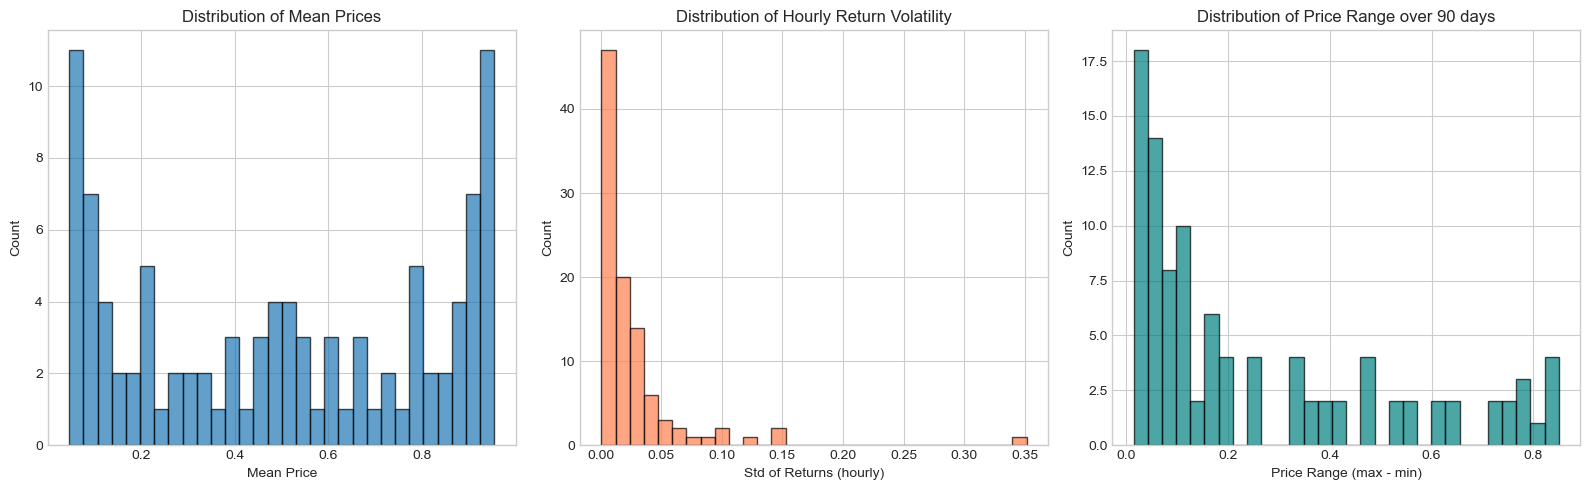

In [2]:
prices = prices.sort_values(["token_id", "timestamp"])
prices["return"] = prices.groupby("token_id")["price"].pct_change()
prices["log_return"] = np.log(prices["price"] / prices.groupby("token_id")["price"].shift(1))
prices["abs_change"] = prices.groupby("token_id")["price"].diff()

token_stats = prices.groupby("token_id").agg(
    n_points=("price", "count"),
    mean_price=("price", "mean"),
    std_price=("price", "std"),
    min_price=("price", "min"),
    max_price=("price", "max"),
    price_range=("price", lambda x: x.max() - x.min()),
    mean_return=("return", "mean"),
    std_return=("return", "std"),
    mean_abs_change=("abs_change", lambda x: x.abs().mean()),
    max_abs_change=("abs_change", lambda x: x.abs().max()),
    question=("question", "first"),
    category=("category", "first"),
    volume=("volumeNum", "first"),
).reset_index()

print(f"Tokens: {len(token_stats)}")
print(f"\n=== Price Distribution ===")
print(token_stats[["mean_price", "std_price", "price_range", "std_return", "max_abs_change"]].describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(token_stats["mean_price"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Mean Price")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Mean Prices")

axes[1].hist(token_stats["std_return"].dropna(), bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("Std of Returns (hourly)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Hourly Return Volatility")

axes[2].hist(token_stats["price_range"], bins=30, edgecolor="black", alpha=0.7, color="teal")
axes[2].set_xlabel("Price Range (max - min)")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of Price Range over 90 days")

plt.tight_layout()
plt.show()

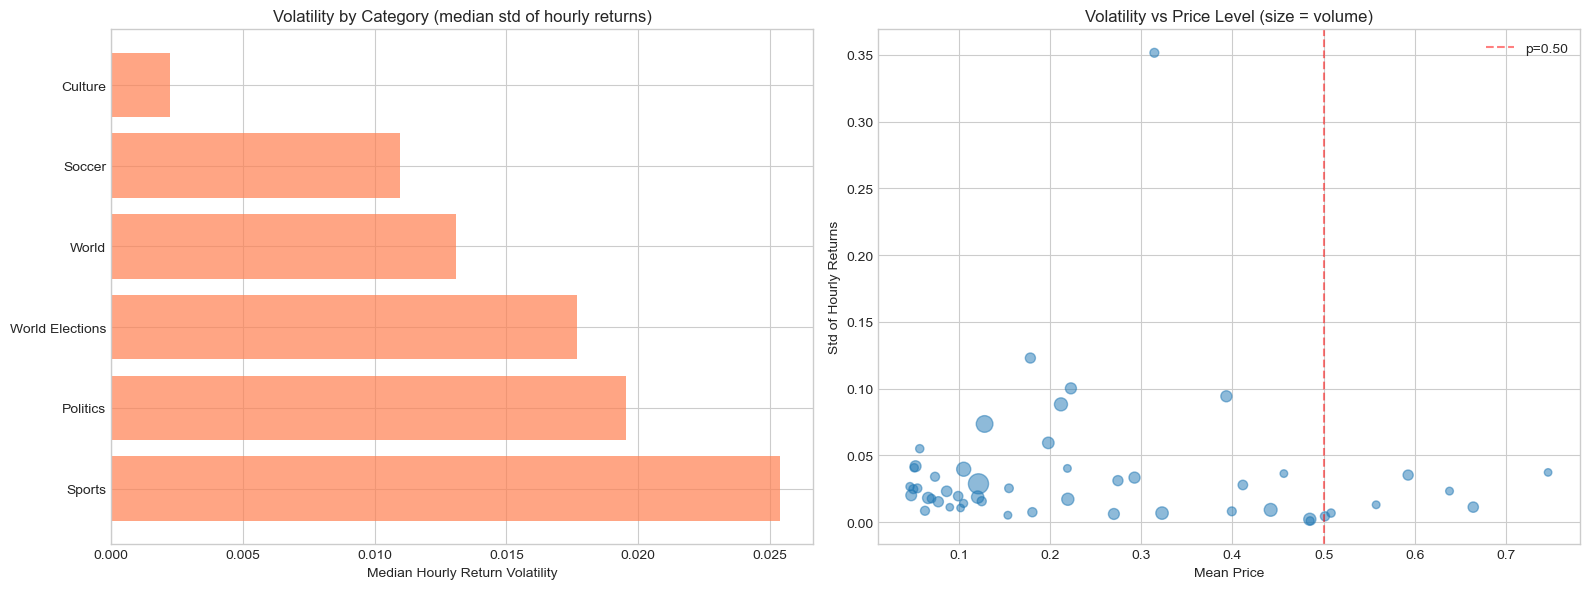

Top 10 most volatile tokens:
  vol=0.3515 | price=0.314 | Will Mojtaba Khamenei be the next Supreme Leader of Iran?
  vol=0.1471 | price=0.681 | ?
  vol=0.1441 | price=0.605 | ?
  vol=0.1230 | price=0.178 | Will there be at least 10000 measles cases in the U.S. in 2026?
  vol=0.1002 | price=0.223 | Will the Iranian regime fall by June 30?
  vol=0.0943 | price=0.393 | Will Nebius Group be acquired before 2027?
  vol=0.0883 | price=0.212 | Will Iran close the Strait of Hormuz by March 31?
  vol=0.0736 | price=0.128 | Will the Iranian regime fall by March 31?
  vol=0.0698 | price=0.792 | ?
  vol=0.0594 | price=0.198 | Will the US acquire part of Greenland in 2026?


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_vol = token_stats.groupby("category")["std_return"].agg(["mean", "median", "count"])
cat_vol = cat_vol[cat_vol["count"] >= 3].sort_values("median", ascending=False)

axes[0].barh(cat_vol.index, cat_vol["median"], color="coral", alpha=0.7)
axes[0].set_xlabel("Median Hourly Return Volatility")
axes[0].set_title("Volatility by Category (median std of hourly returns)")

axes[1].scatter(token_stats["mean_price"], token_stats["std_return"],
                alpha=0.5, s=token_stats["volume"] / token_stats["volume"].max() * 200 + 10)
axes[1].set_xlabel("Mean Price")
axes[1].set_ylabel("Std of Hourly Returns")
axes[1].set_title("Volatility vs Price Level (size = volume)")
axes[1].axvline(0.5, ls="--", color="red", alpha=0.5, label="p=0.50")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Top 10 most volatile tokens:")
for _, row in token_stats.nlargest(10, "std_return").iterrows():
    q = row["question"][:80] if isinstance(row["question"], str) else "?"
    print(f"  vol={row['std_return']:.4f} | price={row['mean_price']:.3f} | {q}")

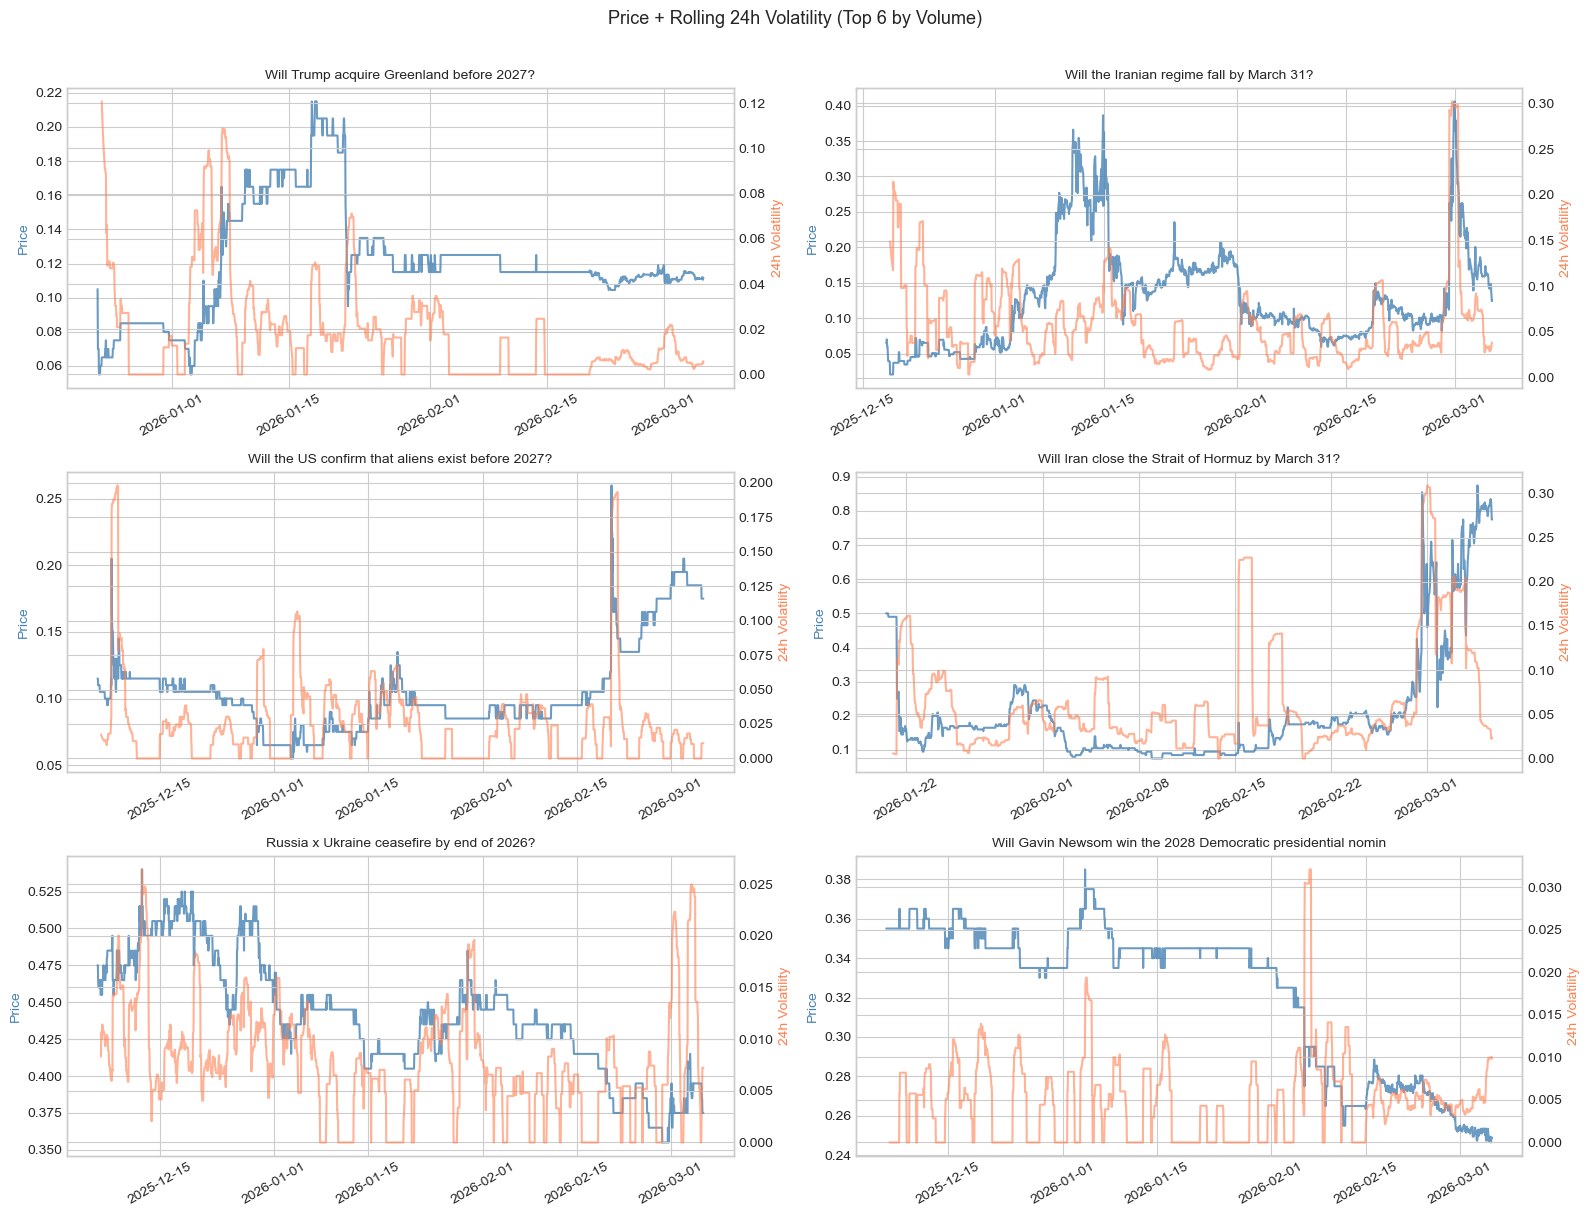

In [4]:
top_tokens = token_stats.nlargest(6, "volume")["token_id"].tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, tid in enumerate(top_tokens):
    tdf = prices[prices["token_id"] == tid].set_index("datetime").sort_index()
    q = tdf["question"].iloc[0][:60] if "question" in tdf.columns else tid[:20]

    tdf["roll_vol"] = tdf["return"].rolling(24, min_periods=12).std()

    ax = axes[i]
    ax2 = ax.twinx()
    ax.plot(tdf.index, tdf["price"], color="steelblue", alpha=0.8, label="Price")
    ax2.plot(tdf.index, tdf["roll_vol"], color="coral", alpha=0.6, label="24h Vol")
    ax.set_title(q, fontsize=10)
    ax.set_ylabel("Price", color="steelblue")
    ax2.set_ylabel("24h Volatility", color="coral")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Price + Rolling 24h Volatility (Top 6 by Volume)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

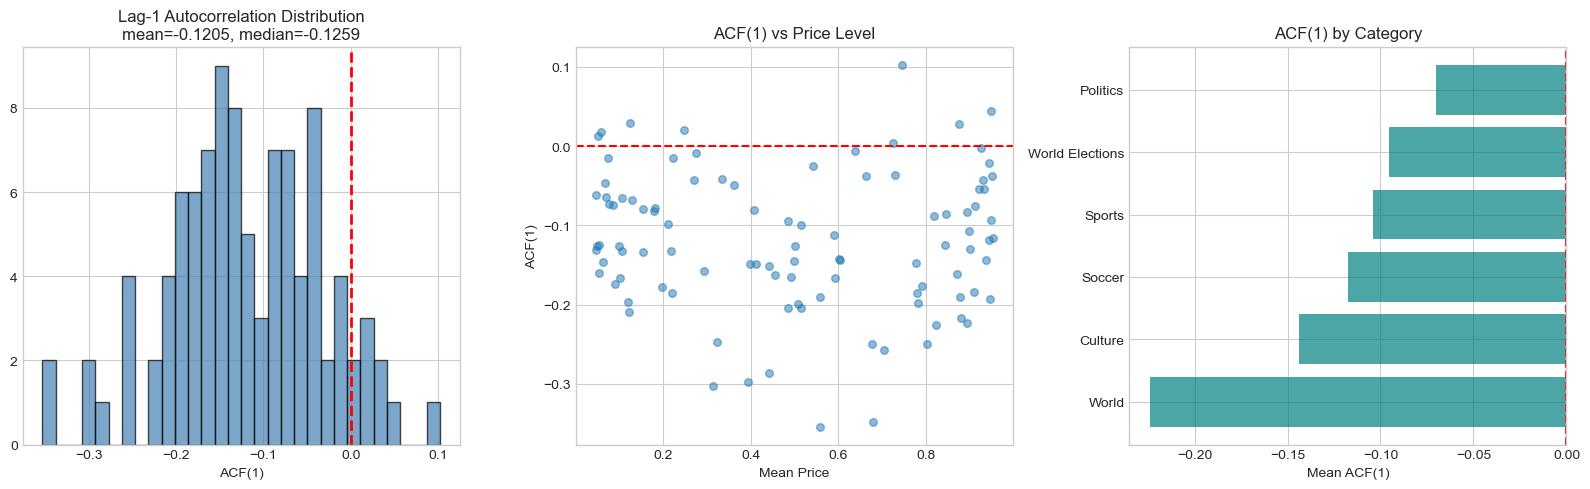


ACF(1) > 0.05 (momentum):      1 tokens (1.0%)
ACF(1) < -0.05 (mean reversion): 77 tokens (77.0%)
|ACF(1)| < 0.05 (random walk):   22 tokens (22.0%)


In [5]:
from statsmodels.tsa.stattools import acf

acf_results = []
for tid, grp in prices.groupby("token_id"):
    rets = grp["return"].dropna()
    if len(rets) < 50:
        continue
    try:
        acf_vals = acf(rets, nlags=10, fft=True)
        acf_results.append({
            "token_id": tid,
            "acf_1": acf_vals[1],
            "acf_2": acf_vals[2],
            "acf_5": acf_vals[5],
            "acf_10": acf_vals[10],
            "question": grp["question"].iloc[0],
            "category": grp["category"].iloc[0],
            "volume": grp["volumeNum"].iloc[0],
            "mean_price": grp["price"].mean(),
        })
    except:
        continue

acf_df = pd.DataFrame(acf_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(acf_df["acf_1"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(0, ls="--", color="red", lw=2)
axes[0].set_xlabel("ACF(1)")
axes[0].set_title(f"Lag-1 Autocorrelation Distribution\nmean={acf_df['acf_1'].mean():.4f}, median={acf_df['acf_1'].median():.4f}")

axes[1].scatter(acf_df["mean_price"], acf_df["acf_1"], alpha=0.5, s=30)
axes[1].axhline(0, ls="--", color="red")
axes[1].set_xlabel("Mean Price")
axes[1].set_ylabel("ACF(1)")
axes[1].set_title("ACF(1) vs Price Level")

cat_acf = acf_df.groupby("category")["acf_1"].agg(["mean", "count"])
cat_acf = cat_acf[cat_acf["count"] >= 3].sort_values("mean")
axes[2].barh(cat_acf.index, cat_acf["mean"], color="teal", alpha=0.7)
axes[2].axvline(0, ls="--", color="red")
axes[2].set_xlabel("Mean ACF(1)")
axes[2].set_title("ACF(1) by Category")

plt.tight_layout()
plt.show()

momentum = (acf_df["acf_1"] > 0.05).sum()
mean_rev = (acf_df["acf_1"] < -0.05).sum()
random_walk = ((acf_df["acf_1"] >= -0.05) & (acf_df["acf_1"] <= 0.05)).sum()
print(f"\nACF(1) > 0.05 (momentum):      {momentum} tokens ({momentum/len(acf_df)*100:.1f}%)")
print(f"ACF(1) < -0.05 (mean reversion): {mean_rev} tokens ({mean_rev/len(acf_df)*100:.1f}%)")
print(f"|ACF(1)| < 0.05 (random walk):   {random_walk} tokens ({random_walk/len(acf_df)*100:.1f}%)")

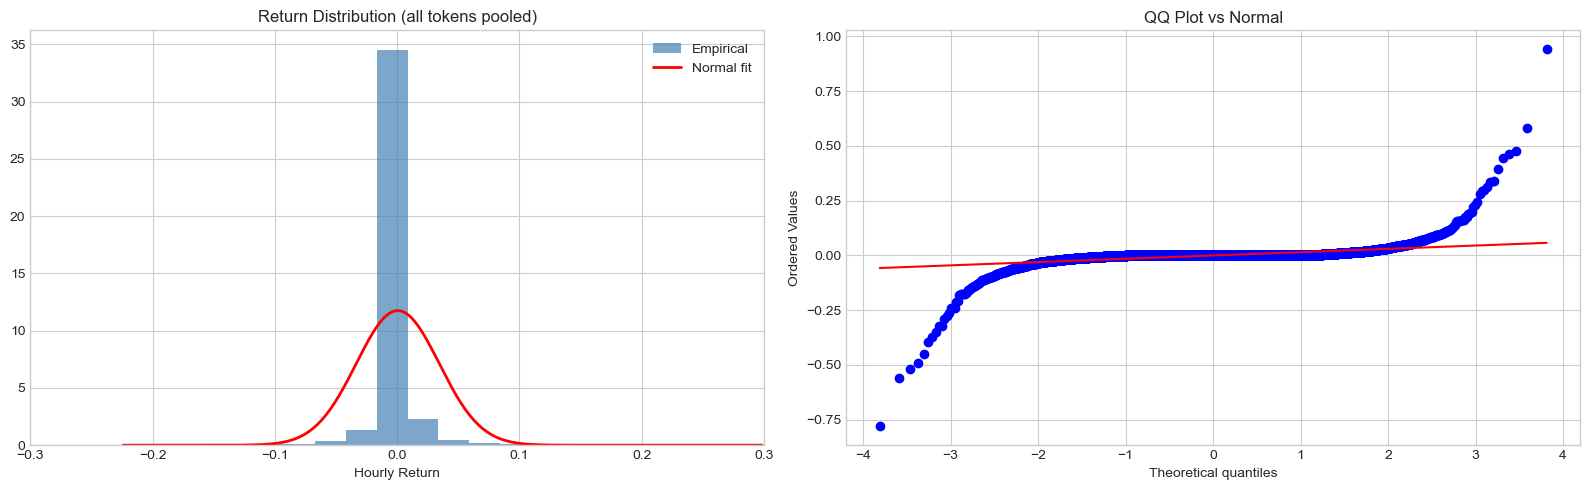

Kurtosis: 4140.34 (Normal = 0, >0 = fat tails)
Skewness: 40.1854 (0 = symmetric)
Jarque-Bera test p-value: 0.00e+00

Per-token kurtosis: mean=131.9, median=55.7
Tokens with kurtosis > 10 (heavy tails): 99 / 100


In [6]:
from scipy import stats

all_returns = prices["return"].dropna()
all_returns = all_returns[(all_returns > -1) & (all_returns < 10)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(all_returns, bins=200, density=True, alpha=0.7, color="steelblue", label="Empirical")
x = np.linspace(all_returns.quantile(0.001), all_returns.quantile(0.999), 300)
axes[0].plot(x, stats.norm.pdf(x, all_returns.mean(), all_returns.std()),
             "r-", lw=2, label="Normal fit")
axes[0].set_xlabel("Hourly Return")
axes[0].set_title("Return Distribution (all tokens pooled)")
axes[0].set_xlim(-0.3, 0.3)
axes[0].legend()

stats.probplot(all_returns.sample(min(10000, len(all_returns)), random_state=SEED), plot=axes[1])
axes[1].set_title("QQ Plot vs Normal")

plt.tight_layout()
plt.show()

kurt = all_returns.kurtosis()
skew = all_returns.skew()
print(f"Kurtosis: {kurt:.2f} (Normal = 0, >0 = fat tails)")
print(f"Skewness: {skew:.4f} (0 = symmetric)")
print(f"Jarque-Bera test p-value: {stats.jarque_bera(all_returns.sample(5000, random_state=SEED))[1]:.2e}")

token_kurt = prices.groupby("token_id")["return"].agg(
    kurtosis=lambda x: x.dropna().kurtosis(),
    skewness=lambda x: x.dropna().skew()
)
print(f"\nPer-token kurtosis: mean={token_kurt['kurtosis'].mean():.1f}, median={token_kurt['kurtosis'].median():.1f}")
print(f"Tokens with kurtosis > 10 (heavy tails): {(token_kurt['kurtosis'] > 10).sum()} / {len(token_kurt)}")

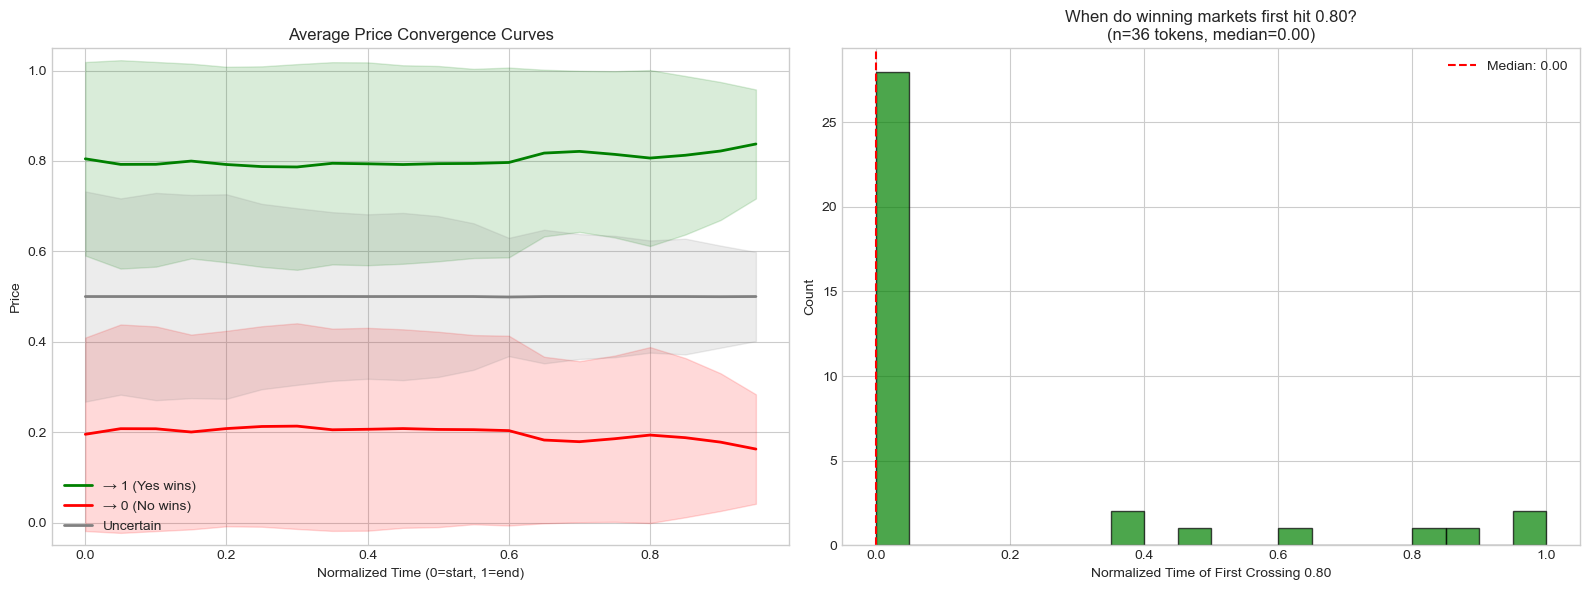

Tokens converging to 1: 38 | to 0: 38 | uncertain: 24


In [7]:
convergence_data = []

for tid, grp in prices.groupby("token_id"):
    grp = grp.sort_values("timestamp")
    if len(grp) < 20:
        continue

    t_min, t_max = grp["timestamp"].min(), grp["timestamp"].max()
    if t_max == t_min:
        continue

    grp = grp.copy()
    grp["t_norm"] = (grp["timestamp"] - t_min) / (t_max - t_min)

    final_price = grp["price"].iloc[-1]
    direction = "converge_1" if final_price > 0.7 else ("converge_0" if final_price < 0.3 else "uncertain")

    bins = np.linspace(0, 1, 21)
    grp["t_bin"] = pd.cut(grp["t_norm"], bins, labels=range(20))
    binned = grp.groupby("t_bin", observed=True)["price"].mean()

    for b, p in binned.items():
        convergence_data.append({"t_bin": int(b), "price": p, "direction": direction, "token_id": tid})

conv_df = pd.DataFrame(convergence_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for direction, color, label in [("converge_1", "green", "→ 1 (Yes wins)"),
                                 ("converge_0", "red", "→ 0 (No wins)"),
                                 ("uncertain", "gray", "Uncertain")]:
    subset = conv_df[conv_df["direction"] == direction]
    if len(subset) == 0:
        continue
    avg = subset.groupby("t_bin")["price"].agg(["mean", "std"])
    axes[0].plot(avg.index / 20, avg["mean"], color=color, lw=2, label=label)
    axes[0].fill_between(avg.index / 20, avg["mean"] - avg["std"], avg["mean"] + avg["std"],
                          alpha=0.15, color=color)

axes[0].set_xlabel("Normalized Time (0=start, 1=end)")
axes[0].set_ylabel("Price")
axes[0].set_title("Average Price Convergence Curves")
axes[0].legend()
axes[0].set_ylim(-0.05, 1.05)

cross_times = []
for tid, grp in prices.groupby("token_id"):
    grp = grp.sort_values("timestamp")
    if len(grp) < 20:
        continue
    final = grp["price"].iloc[-1]
    if final > 0.7:

        above = grp[grp["price"] >= 0.8]
        if len(above) > 0:
            t_cross = (above.iloc[0]["timestamp"] - grp["timestamp"].min()) / (grp["timestamp"].max() - grp["timestamp"].min())
            cross_times.append(t_cross)

if cross_times:
    axes[1].hist(cross_times, bins=20, edgecolor="black", alpha=0.7, color="green")
    axes[1].set_xlabel("Normalized Time of First Crossing 0.80")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"When do winning markets first hit 0.80?\n(n={len(cross_times)} tokens, median={np.median(cross_times):.2f})")
    axes[1].axvline(np.median(cross_times), ls="--", color="red", label=f"Median: {np.median(cross_times):.2f}")
    axes[1].legend()

plt.tight_layout()
plt.show()

n_conv1 = conv_df[conv_df["direction"] == "converge_1"]["token_id"].nunique()
n_conv0 = conv_df[conv_df["direction"] == "converge_0"]["token_id"].nunique()
n_unc = conv_df[conv_df["direction"] == "uncertain"]["token_id"].nunique()
print(f"Tokens converging to 1: {n_conv1} | to 0: {n_conv0} | uncertain: {n_unc}")

Large moves (|Δprice| >= $0.1): 296
  Drops: 144
  Spikes: 152


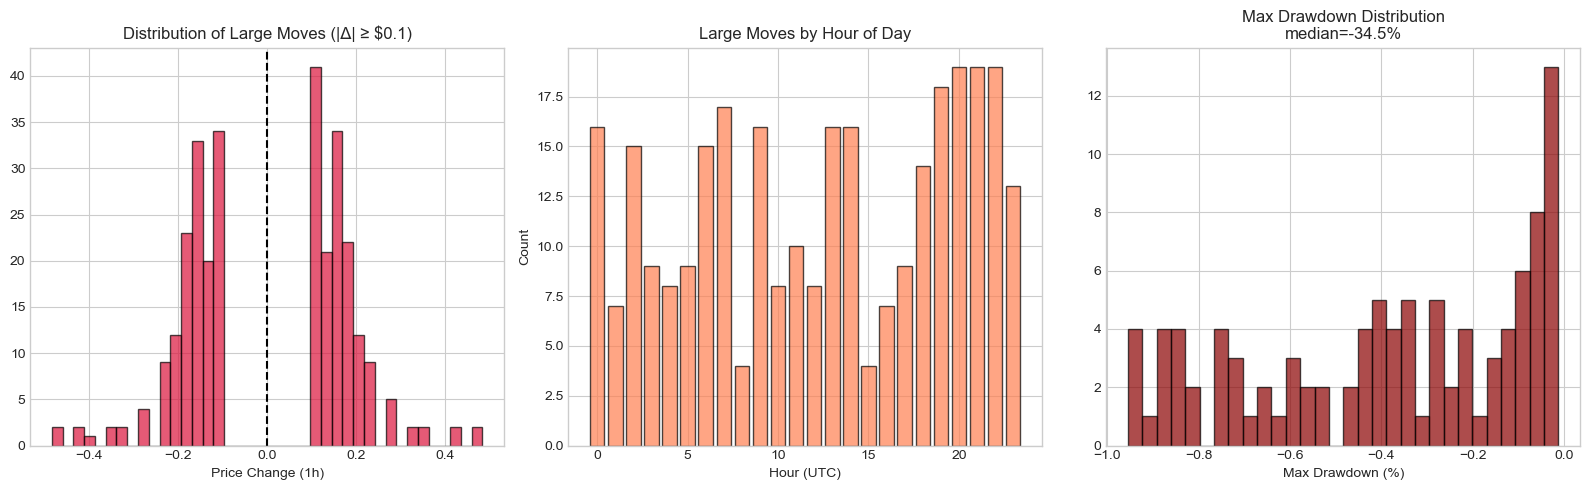


Top 10 largest hourly drops:
  Δ=-0.4840 | price=0.026 | 2025-12-29 18:00:13+00:00 | Will Bitcoin dip to $15,000 by December 31, 2026?
  Δ=-0.4650 | price=0.145 | 2026-02-28 16:00:35+00:00 | ?
  Δ=-0.4300 | price=0.115 | 2026-03-04 19:00:27+00:00 | Will Ken Paxton win the 2026 Texas Republican Primary?
  Δ=-0.4150 | price=0.085 | 2025-12-29 17:00:10+00:00 | Will Bitcoin reach $250,000 by December 31, 2026?
  Δ=-0.3970 | price=0.204 | 2026-03-03 21:00:44+00:00 | ?
  Δ=-0.3605 | price=0.281 | 2026-03-02 10:00:36+00:00 | ?
  Δ=-0.3400 | price=0.055 | 2025-12-14 22:00:14+00:00 | ?
  Δ=-0.3300 | price=0.285 | 2026-03-02 21:00:37+00:00 | ?
  Δ=-0.3150 | price=0.250 | 2026-02-28 07:00:23+00:00 | Will US or Israel strike Iran first?
  Δ=-0.2850 | price=0.225 | 2026-01-29 02:00:14+00:00 | Will Nebius Group be acquired before 2027?


In [8]:
threshold = 0.10
large_moves = prices[prices["abs_change"].abs() >= threshold].copy()
print(f"Large moves (|Δprice| >= ${threshold}): {len(large_moves):,}")
print(f"  Drops: {(large_moves['abs_change'] < 0).sum()}")
print(f"  Spikes: {(large_moves['abs_change'] > 0).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(large_moves["abs_change"], bins=40, edgecolor="black", alpha=0.7, color="crimson")
axes[0].set_xlabel("Price Change (1h)")
axes[0].set_title(f"Distribution of Large Moves (|Δ| ≥ ${threshold})")
axes[0].axvline(0, ls="--", color="black")

large_moves["hour"] = large_moves["datetime"].dt.hour
hourly = large_moves.groupby("hour").size()
axes[1].bar(hourly.index, hourly.values, color="coral", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_ylabel("Count")
axes[1].set_title("Large Moves by Hour of Day")

drawdowns = []
for tid, grp in prices.groupby("token_id"):
    grp = grp.sort_values("timestamp")
    p = grp["price"].values

    running_max = np.maximum.accumulate(p)
    dd = (p - running_max) / np.where(running_max > 0, running_max, 1)
    max_dd = dd.min()
    drawdowns.append({"token_id": tid, "max_drawdown": max_dd,
                       "question": grp["question"].iloc[0] if "question" in grp else ""})

dd_df = pd.DataFrame(drawdowns)
axes[2].hist(dd_df["max_drawdown"], bins=30, edgecolor="black", alpha=0.7, color="darkred")
axes[2].set_xlabel("Max Drawdown (%)")
axes[2].set_title(f"Max Drawdown Distribution\nmedian={dd_df['max_drawdown'].median():.1%}")

plt.tight_layout()
plt.show()

print("\nTop 10 largest hourly drops:")
for _, row in large_moves.nsmallest(10, "abs_change").iterrows():
    q = row.get("question", "")
    q = q[:70] if isinstance(q, str) else "?"
    print(f"  Δ={row['abs_change']:+.4f} | price={row['price']:.3f} | {row['datetime']} | {q}")

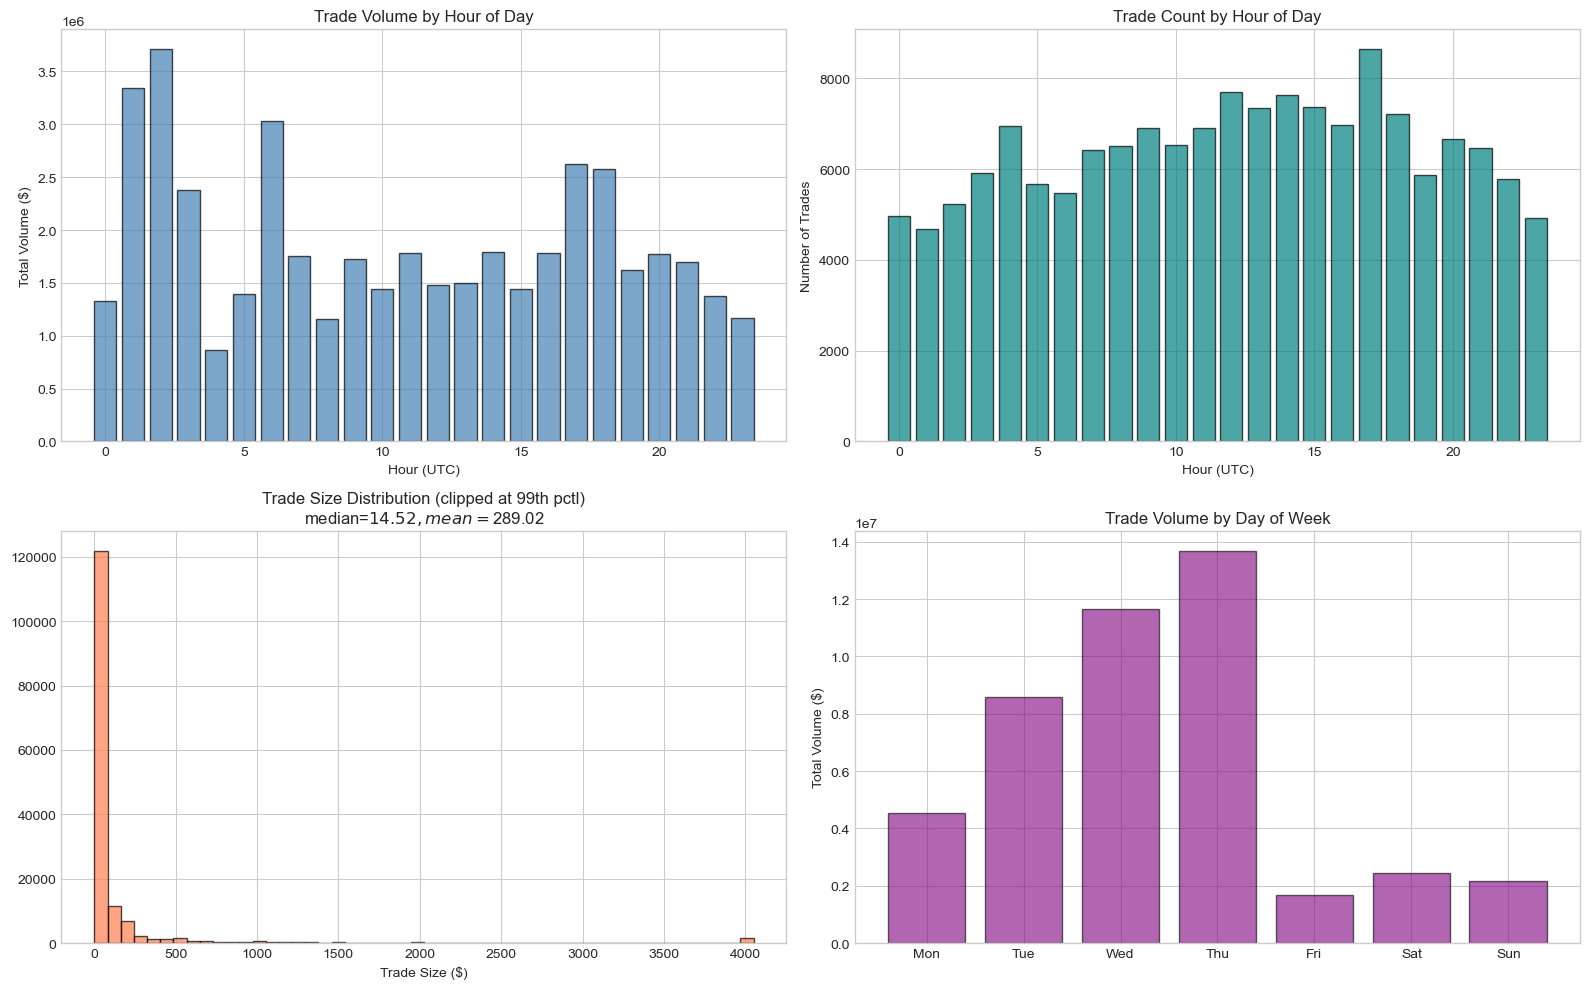


Side distribution: {'BUY': 91338, 'SELL': 63481}
Unique traders: 30,903
Trades per trader: median=2, mean=5.0

Top 10 traders by volume:
  0xefbbed2e... | $4,800,000 | 49 trades
  0x6af15c60... | $3,000,000 | 30 trades
  0x53e55bc7... | $756,942 | 11 trades
  0x79f5efe6... | $342,979 | 4 trades
  0x09a31c68... | $283,446 | 15 trades
  0x72e4daa9... | $238,377 | 3 trades
  0xc6587b11... | $228,761 | 2 trades
  0xde7be6d4... | $227,859 | 6 trades
  0xf9d53577... | $227,014 | 23 trades
  0x5da48936... | $222,523 | 4 trades


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

trades["hour"] = trades["datetime"].dt.hour
hourly_vol = trades.groupby("hour")["size"].agg(["sum", "count"])
axes[0, 0].bar(hourly_vol.index, hourly_vol["sum"], color="steelblue", alpha=0.7, edgecolor="black")
axes[0, 0].set_xlabel("Hour (UTC)")
axes[0, 0].set_ylabel("Total Volume ($)")
axes[0, 0].set_title("Trade Volume by Hour of Day")

axes[0, 1].bar(hourly_vol.index, hourly_vol["count"], color="teal", alpha=0.7, edgecolor="black")
axes[0, 1].set_xlabel("Hour (UTC)")
axes[0, 1].set_ylabel("Number of Trades")
axes[0, 1].set_title("Trade Count by Hour of Day")

trade_sizes = trades["size"].dropna()
trade_sizes = trade_sizes[trade_sizes > 0]
axes[1, 0].hist(trade_sizes.clip(upper=trade_sizes.quantile(0.99)), bins=50,
                edgecolor="black", alpha=0.7, color="coral")
axes[1, 0].set_xlabel("Trade Size ($)")
axes[1, 0].set_title(f"Trade Size Distribution (clipped at 99th pctl)\nmedian=${trade_sizes.median():.2f}, mean=${trade_sizes.mean():.2f}")

trades["dow"] = trades["datetime"].dt.dayofweek
dow_vol = trades.groupby("dow")["size"].sum()
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1, 1].bar(range(7), [dow_vol.get(i, 0) for i in range(7)],
               tick_label=dow_labels, color="purple", alpha=0.6, edgecolor="black")
axes[1, 1].set_ylabel("Total Volume ($)")
axes[1, 1].set_title("Trade Volume by Day of Week")

plt.tight_layout()
plt.show()

side_counts = trades["side"].value_counts()
print(f"\nSide distribution: {side_counts.to_dict()}")
print(f"Unique traders: {trades['proxyWallet'].nunique():,}")
print(f"Trades per trader: median={trades.groupby('proxyWallet').size().median():.0f}, "
      f"mean={trades.groupby('proxyWallet').size().mean():.1f}")

top_traders = trades.groupby("proxyWallet")["size"].sum().nlargest(10)
print(f"\nTop 10 traders by volume:")
for addr, vol in top_traders.items():
    n_trades = (trades["proxyWallet"] == addr).sum()
    print(f"  {addr[:10]}... | ${vol:,.0f} | {n_trades} trades")

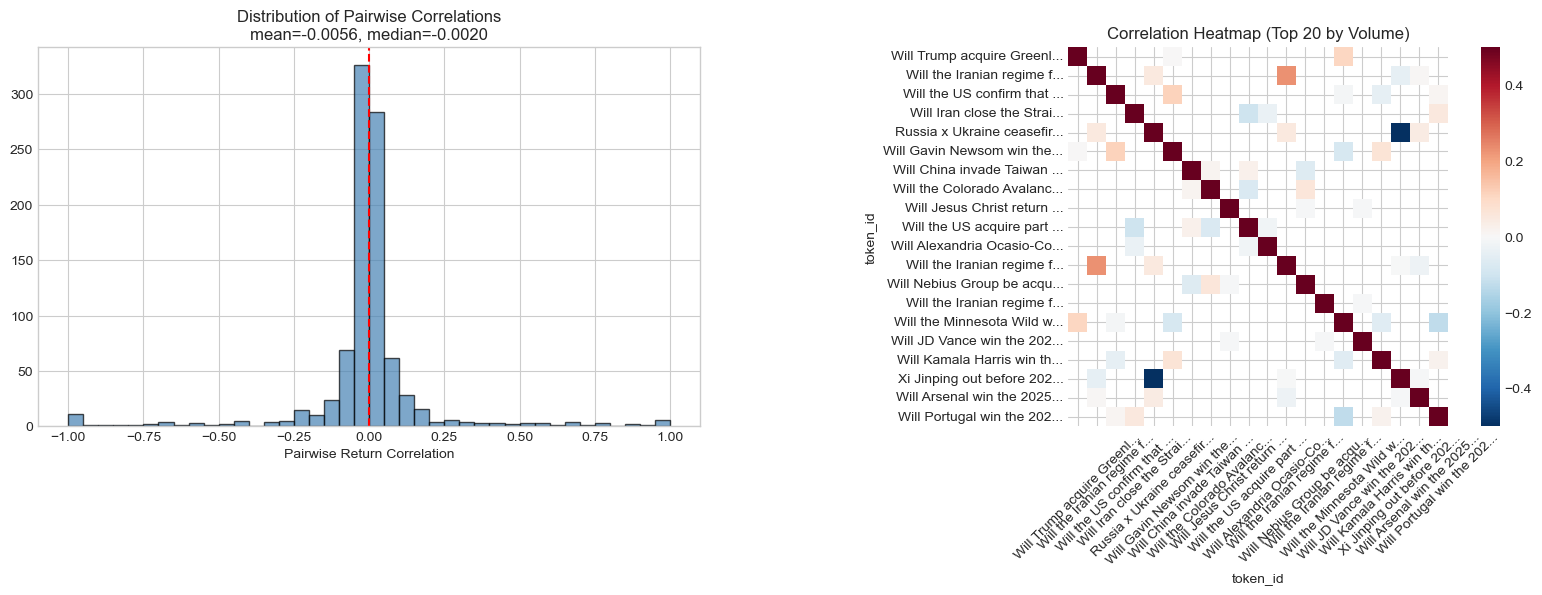


Highly correlated pairs (|r| > 0.3): 73
  r=+1.000 | Will the Colorado Avalanche win the 2026 NHL Stanl <-> 791919396101002
  r=-1.000 | Will the San Antonio Spurs win the 2026 NBA Finals <-> 206155755912612
  r=+1.000 | Russia x Ukraine ceasefire by end of 2026? <-> Will the next Prime Minister of Hungary be Péter M
  r=-1.000 | 106181075047366 <-> Will Trump acquire Greenland before 2027?
  r=-1.000 | Will Alexandria Ocasio-Cortez win the 2028 Democra <-> Will Brazil win the 2026 FIFA World Cup?
  r=+1.000 | Will Flávio Bolsonaro win the 2026 Brazilian presi <-> 873306899062240
  r=-1.000 | 114939266192868 <-> Will Alexandria Ocasio-Cortez win the 2028 US Pres
  r=-1.000 | 126360350705658 <-> Will Marco Rubio win the 2028 Republican president
  r=+1.000 | Will Kamala Harris win the 2028 Democratic preside <-> 449144656372973
  r=-1.000 | Will Gavin Newsom win the 2028 Democratic presiden <-> 878541741480746


In [10]:
active_tokens = token_stats[token_stats["n_points"] >= 500]["token_id"].tolist()
prices_active = prices[prices["token_id"].isin(active_tokens)]

returns_pivot = prices_active.pivot_table(index="timestamp", columns="token_id", values="return")

corr_matrix = returns_pivot.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_values = corr_matrix.where(~mask).stack().values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(corr_values, bins=40, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(0, ls="--", color="red")
axes[0].set_xlabel("Pairwise Return Correlation")
axes[0].set_title(f"Distribution of Pairwise Correlations\n"
                   f"mean={np.nanmean(corr_values):.4f}, median={np.nanmedian(corr_values):.4f}")

top20 = token_stats.nlargest(20, "volume")["token_id"].tolist()
top20_in_active = [t for t in top20 if t in corr_matrix.columns]
if len(top20_in_active) >= 5:
    corr_sub = corr_matrix.loc[top20_in_active, top20_in_active]

    labels = []
    for tid in top20_in_active:
        q = token_stats[token_stats["token_id"] == tid]["question"].values
        lbl = str(q[0])[:25] + "..." if len(q) > 0 and pd.notna(q[0]) else tid[:10]
        labels.append(lbl)

    sns.heatmap(corr_sub, ax=axes[1], cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
                xticklabels=labels, yticklabels=labels, square=True)
    axes[1].set_title("Correlation Heatmap (Top 20 by Volume)")
    axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

def _safe_label(token_id):
    q = token_stats[token_stats["token_id"] == token_id]["question"].values
    if len(q) > 0 and pd.notna(q[0]):
        return str(q[0])[:50]
    return token_id[:15]

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.3:
            t1, t2 = corr_matrix.columns[i], corr_matrix.columns[j]
            high_corr.append({"corr": c, "q1": _safe_label(t1), "q2": _safe_label(t2)})

if high_corr:
    high_corr.sort(key=lambda x: abs(x["corr"]), reverse=True)
    print(f"\nHighly correlated pairs (|r| > 0.3): {len(high_corr)}")
    for hc in high_corr[:10]:
        print(f"  r={hc['corr']:+.3f} | {hc['q1']} <-> {hc['q2']}")
else:
    print("No pairs with |correlation| > 0.3")

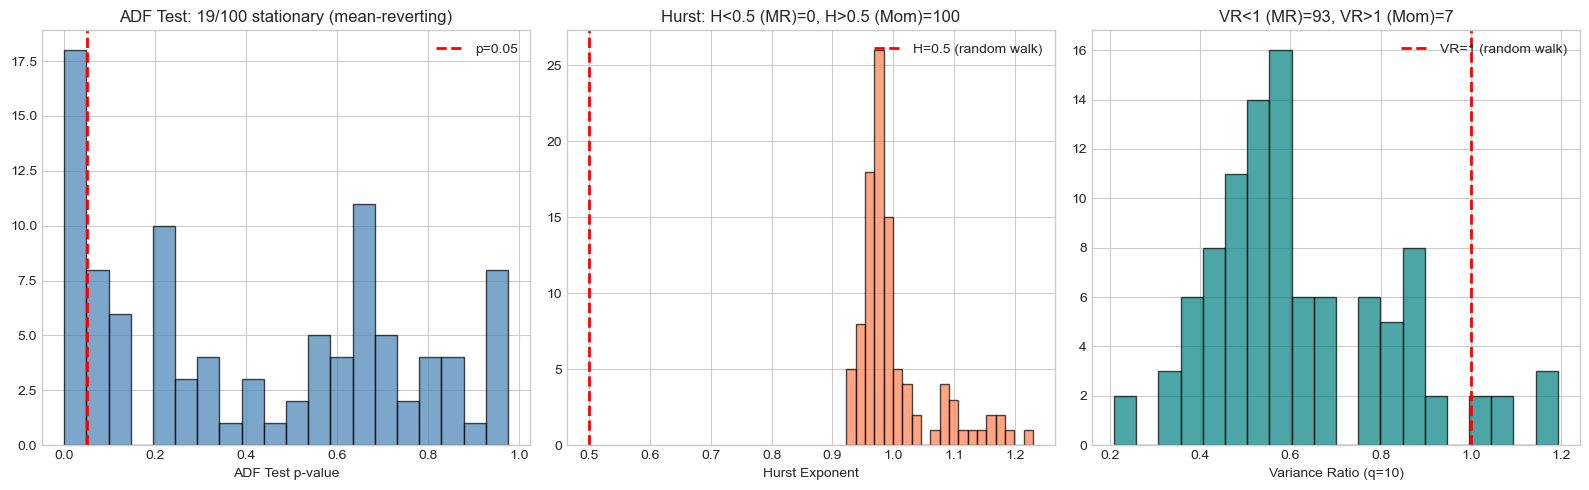

=== Regime Detection Summary ===
ADF test (p<0.05, mean-reverting): 19/100 (19%)
Hurst < 0.5 (mean reversion):     0/100
Hurst > 0.5 (momentum):           100/100
Variance Ratio < 1 (MR):          93/100

Hurst mean: 1.001, median: 0.979
VR mean: 0.621, median: 0.565


In [11]:
from statsmodels.tsa.stattools import adfuller

def hurst_exponent(ts, max_lag=50):
    """Hurst exponent via R/S analysis."""
    ts = np.array(ts)
    lags = range(2, min(max_lag, len(ts) // 4))
    rs = []
    for lag in lags:
        chunks = [ts[i:i+lag] for i in range(0, len(ts) - lag, lag)]
        rs_vals = []
        for chunk in chunks:
            if len(chunk) < 2:
                continue
            mean_adj = chunk - np.mean(chunk)
            cumsum = np.cumsum(mean_adj)
            R = np.max(cumsum) - np.min(cumsum)
            S = np.std(chunk, ddof=1)
            if S > 0:
                rs_vals.append(R / S)
        if rs_vals:
            rs.append(np.mean(rs_vals))
        else:
            rs.append(np.nan)
    rs = np.array(rs)
    valid = ~np.isnan(rs) & (rs > 0)
    if valid.sum() < 3:
        return np.nan
    log_lags = np.log(np.array(list(lags))[valid])
    log_rs = np.log(rs[valid])
    H = np.polyfit(log_lags, log_rs, 1)[0]
    return H

regime_results = []
for tid, grp in prices.groupby("token_id"):
    p = grp.sort_values("timestamp")["price"].values
    if len(p) < 100:
        continue

    try:
        adf_stat, adf_p, _, _, _, _ = adfuller(p, maxlag=20, regression="c")
    except:
        adf_stat, adf_p = np.nan, np.nan

    H = hurst_exponent(p)

    rets = np.diff(p)
    q = 10
    if len(rets) >= q * 2:
        var_1 = np.var(rets, ddof=1)
        q_rets = np.array([rets[i:i+q].sum() for i in range(0, len(rets) - q + 1, q)])
        var_q = np.var(q_rets, ddof=1) if len(q_rets) > 1 else np.nan
        vr = var_q / (q * var_1) if var_1 > 0 else np.nan
    else:
        vr = np.nan

    regime_results.append({
        "token_id": tid,
        "adf_stat": adf_stat, "adf_p": adf_p,
        "hurst": H, "var_ratio": vr,
        "question": grp["question"].iloc[0],
        "category": grp["category"].iloc[0],
    })

regime_df = pd.DataFrame(regime_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(regime_df["adf_p"].dropna(), bins=20, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(0.05, ls="--", color="red", lw=2, label="p=0.05")
axes[0].set_xlabel("ADF Test p-value")
axes[0].set_title(f"ADF Test: {(regime_df['adf_p'] < 0.05).sum()}/{len(regime_df)} "
                   f"stationary (mean-reverting)")
axes[0].legend()

axes[1].hist(regime_df["hurst"].dropna(), bins=20, edgecolor="black", alpha=0.7, color="coral")
axes[1].axvline(0.5, ls="--", color="red", lw=2, label="H=0.5 (random walk)")
axes[1].set_xlabel("Hurst Exponent")
axes[1].set_title(f"Hurst: H<0.5 (MR)={regime_df[regime_df['hurst']<0.5].shape[0]}, "
                   f"H>0.5 (Mom)={regime_df[regime_df['hurst']>0.5].shape[0]}")
axes[1].legend()

vr_valid = regime_df["var_ratio"].dropna()
axes[2].hist(vr_valid.clip(0, 3), bins=20, edgecolor="black", alpha=0.7, color="teal")
axes[2].axvline(1.0, ls="--", color="red", lw=2, label="VR=1 (random walk)")
axes[2].set_xlabel("Variance Ratio (q=10)")
axes[2].set_title(f"VR<1 (MR)={vr_valid[vr_valid<1].shape[0]}, VR>1 (Mom)={vr_valid[vr_valid>1].shape[0]}")
axes[2].legend()

plt.tight_layout()
plt.show()

print("=== Regime Detection Summary ===")
print(f"ADF test (p<0.05, mean-reverting): {(regime_df['adf_p']<0.05).sum()}/{len(regime_df)} "
      f"({(regime_df['adf_p']<0.05).mean()*100:.0f}%)")
print(f"Hurst < 0.5 (mean reversion):     {(regime_df['hurst']<0.5).sum()}/{regime_df['hurst'].notna().sum()}")
print(f"Hurst > 0.5 (momentum):           {(regime_df['hurst']>0.5).sum()}/{regime_df['hurst'].notna().sum()}")
print(f"Variance Ratio < 1 (MR):          {(vr_valid<1).sum()}/{len(vr_valid)}")
print(f"\nHurst mean: {regime_df['hurst'].mean():.3f}, median: {regime_df['hurst'].median():.3f}")
print(f"VR mean: {vr_valid.mean():.3f}, median: {vr_valid.median():.3f}")

Resolved markets: 321,939
Outcome: Yes=127,156, No=194,783


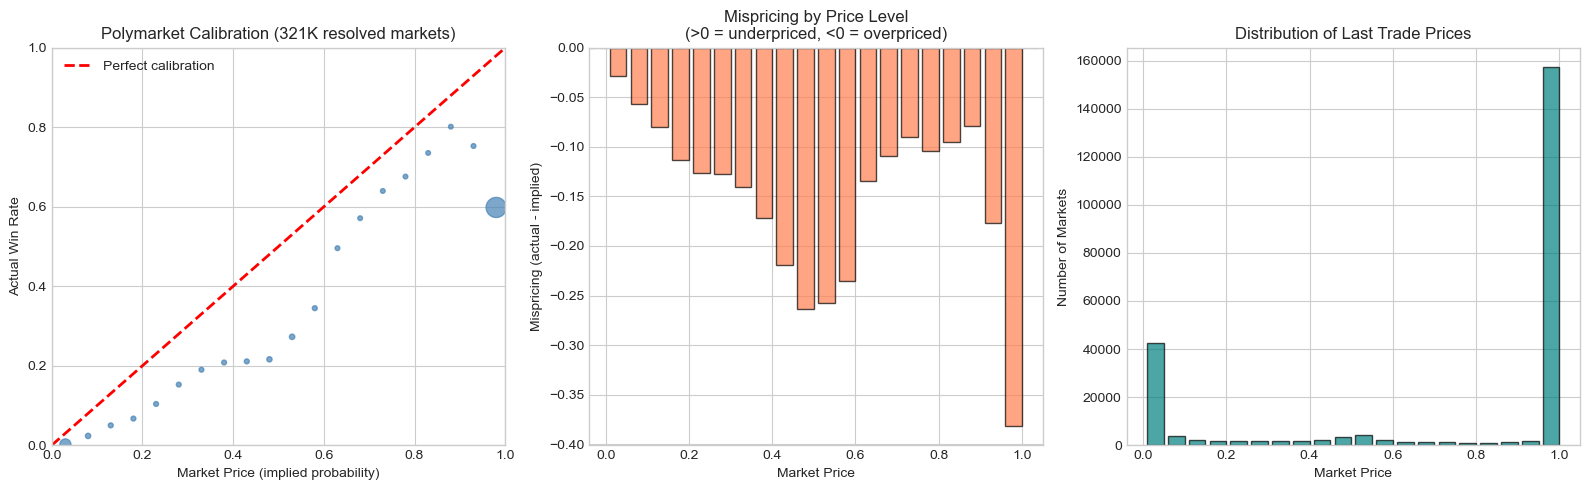


Brier Score: 0.3090 (lower is better, perfect=0, random=0.25)



Longshots (price < $0.20): 97,993
  Win rate: 0.185 (expected: ~0.012)
  Bias: +0.173

Favourites (price > $0.80): 161,217
  Win rate: 0.602 (expected: ~0.996)
  Bias: -0.394

YES bias: avg price=0.612, actual YES rate=0.395, diff=+0.217
(>0 means YES is overpriced = YES bias confirmed)


In [12]:
outcomes = pd.read_parquet(PROCESSED / "resolution_outcomes.parquet")
print(f"Resolved markets: {len(outcomes):,}")
print(f"Outcome: Yes={outcomes['outcome'].sum():,}, No={(outcomes['outcome']==0).sum():,}")

outcomes["price_bin"] = pd.cut(outcomes["lastTradePrice"], bins=np.arange(0, 1.05, 0.05),
                                labels=[f"{x:.2f}" for x in np.arange(0.025, 1.0, 0.05)])
cal = outcomes.groupby("price_bin", observed=True).agg(
    win_rate=("outcome", "mean"),
    count=("outcome", "count"),
    avg_volume=("volumeNum", "mean"),
).reset_index()
cal["price_mid"] = [float(x) for x in cal["price_bin"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(cal["price_mid"], cal["win_rate"], s=cal["count"] / cal["count"].max() * 200 + 10,
                alpha=0.7, color="steelblue")
axes[0].plot([0, 1], [0, 1], "r--", lw=2, label="Perfect calibration")
axes[0].set_xlabel("Market Price (implied probability)")
axes[0].set_ylabel("Actual Win Rate")
axes[0].set_title("Polymarket Calibration (321K resolved markets)")
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

cal["mispricing"] = cal["win_rate"] - cal["price_mid"]
axes[1].bar(cal["price_mid"], cal["mispricing"], width=0.04, color="coral", alpha=0.7, edgecolor="black")
axes[1].axhline(0, ls="--", color="black")
axes[1].set_xlabel("Market Price")
axes[1].set_ylabel("Mispricing (actual - implied)")
axes[1].set_title("Mispricing by Price Level\n(>0 = underpriced, <0 = overpriced)")

axes[2].bar(cal["price_mid"], cal["count"], width=0.04, color="teal", alpha=0.7, edgecolor="black")
axes[2].set_xlabel("Market Price")
axes[2].set_ylabel("Number of Markets")
axes[2].set_title("Distribution of Last Trade Prices")

plt.tight_layout()
plt.show()

brier = np.mean((outcomes["lastTradePrice"] - outcomes["outcome"]) ** 2)
print(f"\nBrier Score: {brier:.4f} (lower is better, perfect=0, random=0.25)")

longshots = outcomes[outcomes["lastTradePrice"] < 0.20]
favourites = outcomes[outcomes["lastTradePrice"] > 0.80]
print(f"\nLongshots (price < $0.20): {len(longshots):,}")
print(f"  Win rate: {longshots['outcome'].mean():.3f} (expected: ~{longshots['lastTradePrice'].mean():.3f})")
print(f"  Bias: {longshots['outcome'].mean() - longshots['lastTradePrice'].mean():+.3f}")

print(f"\nFavourites (price > $0.80): {len(favourites):,}")
print(f"  Win rate: {favourites['outcome'].mean():.3f} (expected: ~{favourites['lastTradePrice'].mean():.3f})")
print(f"  Bias: {favourites['outcome'].mean() - favourites['lastTradePrice'].mean():+.3f}")

yes_rate = outcomes["outcome"].mean()
avg_price = outcomes["lastTradePrice"].mean()
print(f"\nYES bias: avg price={avg_price:.3f}, actual YES rate={yes_rate:.3f}, diff={avg_price-yes_rate:+.3f}")
print("(>0 means YES is overpriced = YES bias confirmed)" if avg_price > yes_rate else "(no YES bias)")

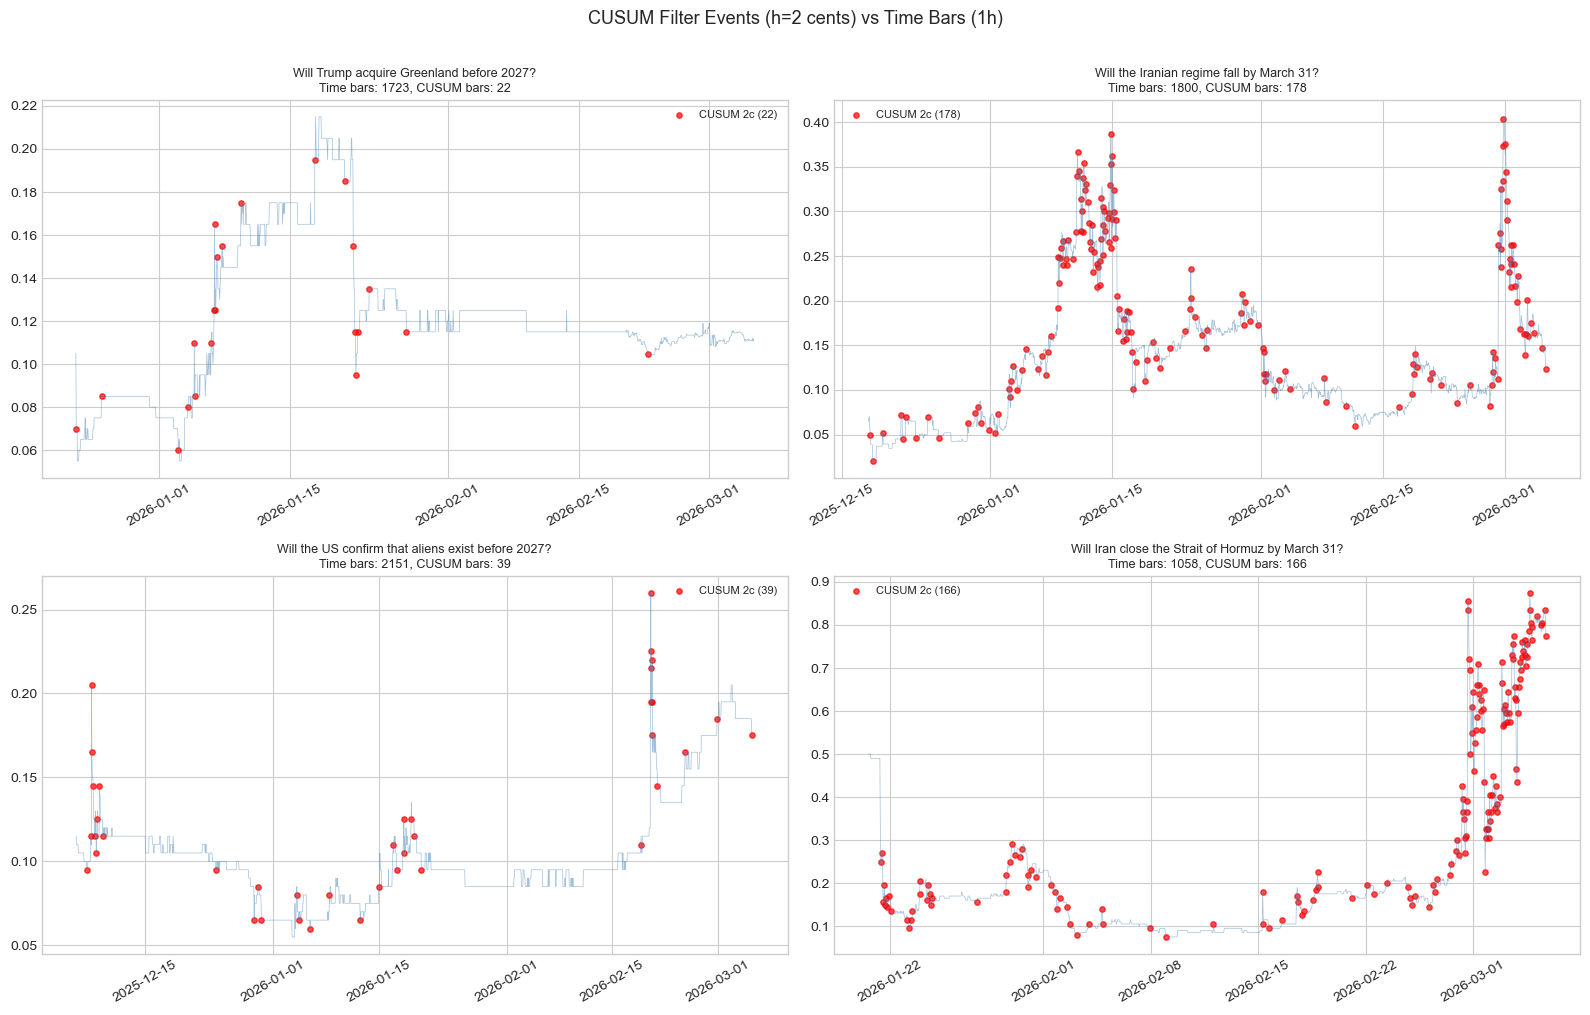

=== CUSUM vs Time Bars Summary ===
                                          question  time_bars  cusum_2c  cusum_5c  ratio_2c
         Will Trump acquire Greenland before 2027?       1723        22         5  0.012768
         Will the Iranian regime fall by March 31?       1800       178        48  0.098889
Will the US confirm that aliens exist before 2027?       2151        39         9  0.018131
 Will Iran close the Strait of Hormuz by March 31?       1058       166        73  0.156900

CUSUM reduction: 93% fewer bars on average
→ CUSUM filters out noise periods, focuses on meaningful price movements


In [13]:
def cusum_filter(prices_series, h):
    """CUSUM filter: create event when cumulative sum exceeds threshold h.
    Returns timestamps of CUSUM events."""
    events = []
    s_pos, s_neg = 0.0, 0.0
    diff = prices_series.diff().dropna()

    for i, (ts, d) in enumerate(diff.items()):
        s_pos = max(0, s_pos + d)
        s_neg = min(0, s_neg + d)
        if s_pos >= h:
            events.append(ts)
            s_pos = 0
        elif abs(s_neg) >= h:
            events.append(ts)
            s_neg = 0
    return events

sample_tokens = token_stats.nlargest(4, "volume")["token_id"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

cusum_stats = []
for i, tid in enumerate(sample_tokens):
    tdf = prices[prices["token_id"] == tid].sort_values("timestamp").set_index("datetime")
    q = tdf["question"].iloc[0][:50] if pd.notna(tdf["question"].iloc[0]) else tid[:15]
    p = tdf["price"]

    events_002 = cusum_filter(p, h=0.02)
    events_005 = cusum_filter(p, h=0.05)

    cusum_stats.append({
        "question": q,
        "time_bars": len(p),
        "cusum_2c": len(events_002),
        "cusum_5c": len(events_005),
        "ratio_2c": len(events_002) / len(p) if len(p) > 0 else 0,
    })

    ax = axes[i]
    ax.plot(p.index, p.values, color="steelblue", alpha=0.5, lw=0.5)

    if events_002:
        cusum_idx = p.index.isin(events_002)
        ax.scatter(p.index[cusum_idx], p.values[cusum_idx], color="red", s=15, alpha=0.7,
                   label=f"CUSUM 2c ({len(events_002)})")
    ax.set_title(f"{q}\nTime bars: {len(p)}, CUSUM bars: {len(events_002)}", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("CUSUM Filter Events (h=2 cents) vs Time Bars (1h)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

cs_df = pd.DataFrame(cusum_stats)
print("=== CUSUM vs Time Bars Summary ===")
print(cs_df[["question", "time_bars", "cusum_2c", "cusum_5c", "ratio_2c"]].to_string(index=False))
print(f"\nCUSUM reduction: {(1 - cs_df['ratio_2c'].mean())*100:.0f}% fewer bars on average")
print("→ CUSUM filters out noise periods, focuses on meaningful price movements")

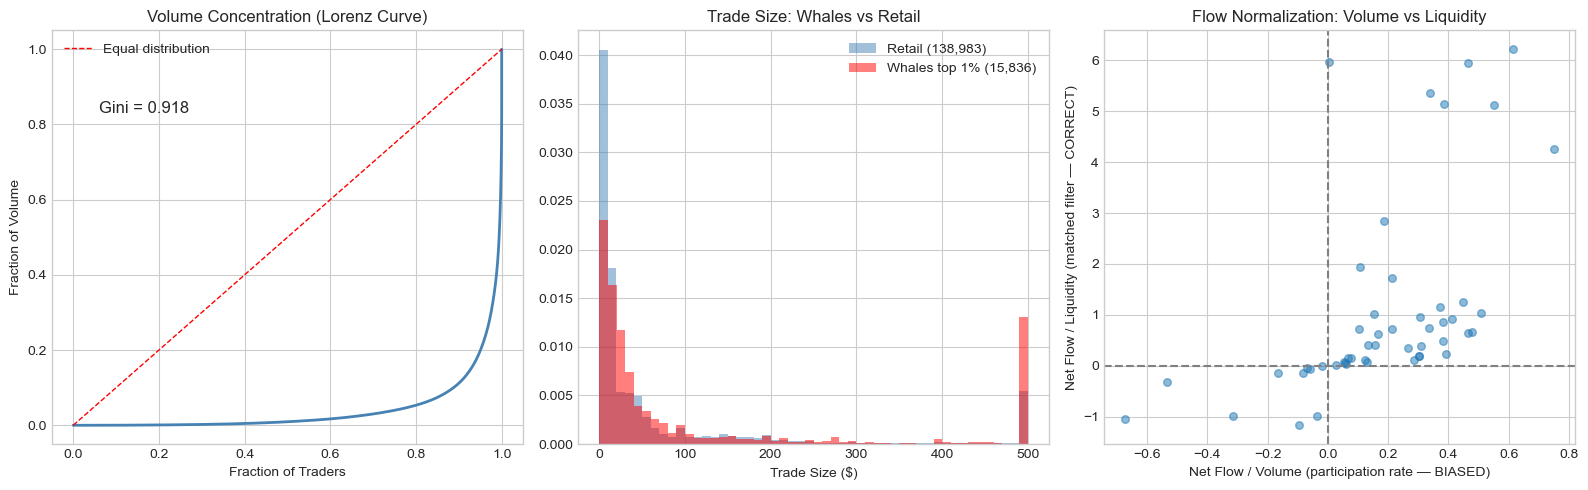

Volume concentration:
  Top 1% traders: 57.2% of total volume
  Top 10% traders: 88.8% of total volume
  Gini coefficient: 0.918

Whale avg trade size: $1619 vs retail: $138

Correlation between normalizations: 0.542
(Low correlation → normalization method MATTERS, as per Matched Filter paper)


In [14]:
trader_vol = trades.groupby("proxyWallet").agg(
    total_volume=("size", "sum"),
    n_trades=("size", "count"),
    avg_size=("size", "mean"),
    n_markets=("conditionId", "nunique"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sorted_vol = trader_vol["total_volume"].sort_values().values
cumsum_vol = np.cumsum(sorted_vol) / sorted_vol.sum()
x = np.arange(len(cumsum_vol)) / len(cumsum_vol)

axes[0].plot(x, cumsum_vol, color="steelblue", lw=2)
axes[0].plot([0, 1], [0, 1], "r--", lw=1, label="Equal distribution")
axes[0].set_xlabel("Fraction of Traders")
axes[0].set_ylabel("Fraction of Volume")
axes[0].set_title("Volume Concentration (Lorenz Curve)")
axes[0].legend()

gini = 1 - 2 * np.trapezoid(cumsum_vol, x)
axes[0].text(0.1, 0.8, f"Gini = {gini:.3f}", fontsize=12, transform=axes[0].transAxes)

whale_threshold = trader_vol["total_volume"].quantile(0.99)
whales = trader_vol[trader_vol["total_volume"] >= whale_threshold]["proxyWallet"]
is_whale = trades["proxyWallet"].isin(whales)

whale_sizes = trades[is_whale]["size"]
retail_sizes = trades[~is_whale]["size"]

axes[1].hist(retail_sizes.clip(upper=500), bins=50, alpha=0.5, color="steelblue",
             label=f"Retail ({(~is_whale).sum():,})", density=True)
axes[1].hist(whale_sizes.clip(upper=500), bins=50, alpha=0.5, color="red",
             label=f"Whales top 1% ({is_whale.sum():,})", density=True)
axes[1].set_xlabel("Trade Size ($)")
axes[1].set_title("Trade Size: Whales vs Retail")
axes[1].legend()

flow_data = []
for cid, g in trades.groupby("conditionId"):
    buy_vol = g[g["side"] == "BUY"]["size"].sum()
    sell_vol = g[g["side"] == "SELL"]["size"].sum()
    flow_data.append({
        "conditionId": cid,
        "net_flow": buy_vol - sell_vol,
        "total_volume": g["size"].sum(),
        "n_trades": len(g),
    })
market_flow = pd.DataFrame(flow_data)

market_flow = market_flow.merge(
    markets[["conditionId", "liquidityClob", "volumeNum"]].drop_duplicates("conditionId"),
    on="conditionId", how="left"
)
market_flow["flow_ratio_volume"] = market_flow["net_flow"] / market_flow["total_volume"]
market_flow["flow_ratio_liquidity"] = market_flow["net_flow"] / market_flow["liquidityClob"].clip(lower=1)

axes[2].scatter(market_flow["flow_ratio_volume"], market_flow["flow_ratio_liquidity"],
                alpha=0.5, s=30)
axes[2].axhline(0, ls="--", color="gray")
axes[2].axvline(0, ls="--", color="gray")
axes[2].set_xlabel("Net Flow / Volume (participation rate — BIASED)")
axes[2].set_ylabel("Net Flow / Liquidity (matched filter — CORRECT)")
axes[2].set_title("Flow Normalization: Volume vs Liquidity")

plt.tight_layout()
plt.show()

top1_share = trader_vol.nlargest(int(len(trader_vol)*0.01), "total_volume")["total_volume"].sum() / trader_vol["total_volume"].sum()
top10_share = trader_vol.nlargest(int(len(trader_vol)*0.1), "total_volume")["total_volume"].sum() / trader_vol["total_volume"].sum()
print(f"Volume concentration:")
print(f"  Top 1% traders: {top1_share:.1%} of total volume")
print(f"  Top 10% traders: {top10_share:.1%} of total volume")
print(f"  Gini coefficient: {gini:.3f}")
print(f"\nWhale avg trade size: ${whale_sizes.mean():.0f} vs retail: ${retail_sizes.mean():.0f}")
print(f"\nCorrelation between normalizations: {market_flow['flow_ratio_volume'].corr(market_flow['flow_ratio_liquidity']):.3f}")
print("(Low correlation → normalization method MATTERS, as per Matched Filter paper)")

Daily price matrix: 91 days × 98 tokens
Cross-market candidate pairs (0.5<|r|<0.99): 1560


Cross-market cointegrated pairs (p<0.05): 330

Top cross-market cointegrated pairs:
  p=0.0000, corr=+0.561
    Will bitcoin hit $1m before GTA VI?
    Will the US confirm that aliens exist before 2027?
  p=0.0000, corr=-0.561
    Will bitcoin hit $1m before GTA VI?
    730563024980
  p=0.0000, corr=-0.540
    Will bitcoin hit $1m before GTA VI?
    126360350705
  p=0.0000, corr=-0.829
    Will Nebius Group be acquired before 2027?
    Will the Cleveland Cavaliers win the 2026 NBA Finals?
  p=0.0000, corr=+0.829
    Will Nebius Group be acquired before 2027?
    873306899062
  p=0.0000, corr=-0.829
    360130737495
    873306899062
  p=0.0000, corr=-0.689
    284982737259
    879780820716
  p=0.0000, corr=+0.689
    Trump out as President before 2027?
    879780820716
  p=0.0000, corr=-0.705
    Will the US acquire part of Greenland in 2026?
    878541741480
  p=0.0000, corr=-0.705
    104895545296
    Will Gavin Newsom win the 2028 Democratic presidential nomin


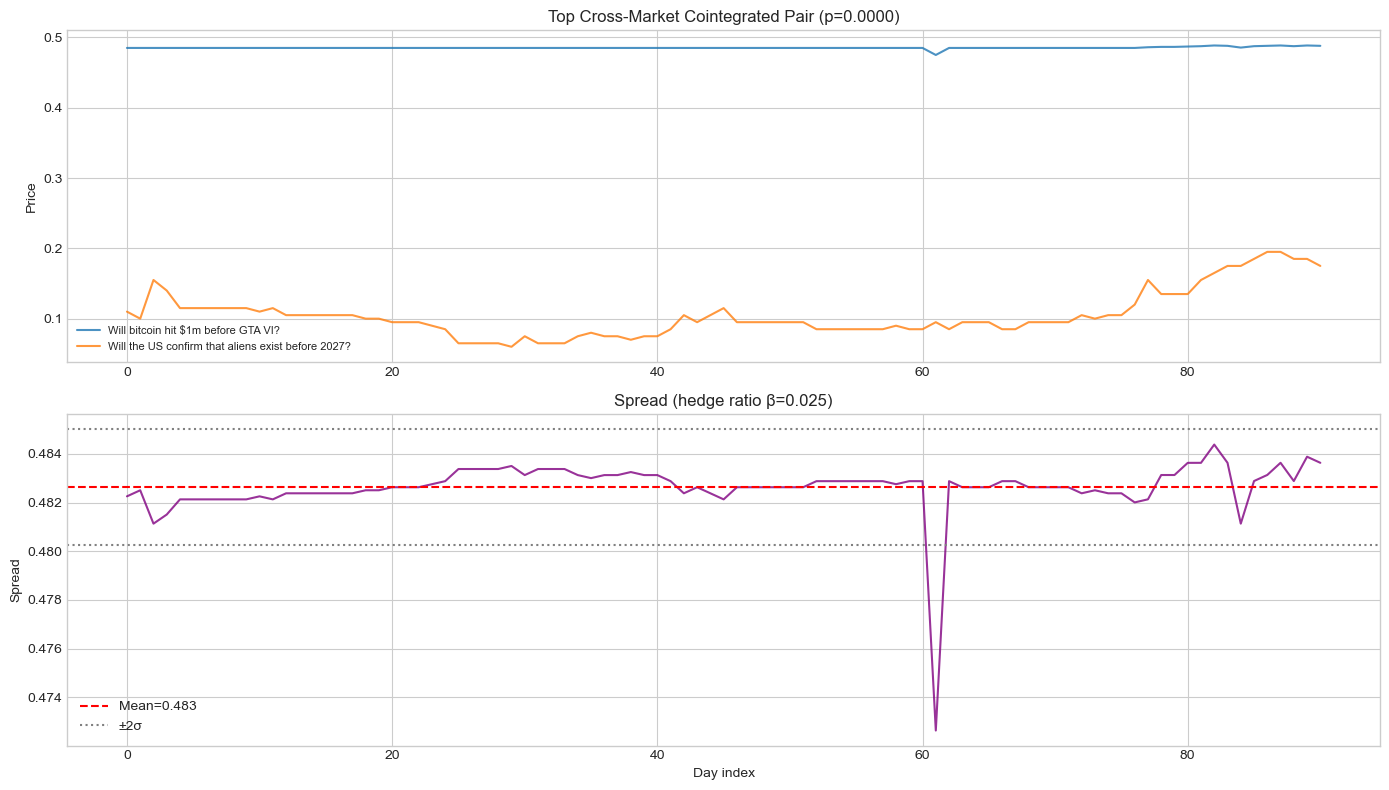


Spread half-life: 0.8 days


In [15]:
import warnings
from statsmodels.tsa.stattools import coint

prices["date"] = prices["datetime"].dt.date
daily = prices.groupby(["token_id", "date"])["price"].last().reset_index()
price_pivot = daily.pivot_table(index="date", columns="token_id", values="price")
min_obs = 30
valid_tokens = price_pivot.columns[price_pivot.notna().sum() >= min_obs].tolist()
price_mat = price_pivot[valid_tokens].dropna(axis=0, how="all").ffill()
print(f"Daily price matrix: {price_mat.shape[0]} days × {len(valid_tokens)} tokens")

token_to_cond = prices.drop_duplicates("token_id").set_index("token_id")["conditionId"].to_dict()

corr_mat = price_mat.corr()
candidate_pairs = []
tokens = price_mat.columns.tolist()
for i in range(len(tokens)):
    for j in range(i+1, len(tokens)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.5 and abs(r) < 0.99:
            ci = token_to_cond.get(tokens[i])
            cj = token_to_cond.get(tokens[j])
            if ci and cj and ci != cj:
                candidate_pairs.append((tokens[i], tokens[j], r))
print(f"Cross-market candidate pairs (0.5<|r|<0.99): {len(candidate_pairs)}")

pairs_results = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for ti, tj, r in candidate_pairs:
        s1 = price_mat[ti].dropna()
        s2 = price_mat[tj].dropna()
        common = s1.index.intersection(s2.index)
        if len(common) < min_obs:
            continue
        try:
            stat, pval, crit = coint(s1.loc[common], s2.loc[common])
            if pval < 0.05:
                pairs_results.append({
                    "token_i": ti, "token_j": tj,
                    "coint_stat": stat, "pval": pval, "corr": r,
                })
        except Exception:
            continue

pairs_df = pd.DataFrame(pairs_results).sort_values("pval")
print(f"Cross-market cointegrated pairs (p<0.05): {len(pairs_df)}")

if len(pairs_df) > 0:
    def get_label(tid):
        mask = markets["token_id_yes"] == tid
        if mask.any():
            q = markets.loc[mask, "question"].iloc[0]
            return q[:60] if pd.notna(q) else tid[:12]
        return tid[:12]

    print(f"\nTop cross-market cointegrated pairs:")
    for _, row in pairs_df.head(10).iterrows():
        print(f"  p={row['pval']:.4f}, corr={row['corr']:+.3f}")
        print(f"    {get_label(row['token_i'])}")
        print(f"    {get_label(row['token_j'])}")

    top = pairs_df.iloc[0]
    s1 = price_mat[top["token_i"]].dropna()
    s2 = price_mat[top["token_j"]].dropna()
    common = s1.index.intersection(s2.index)

    beta = np.polyfit(s2.loc[common], s1.loc[common], 1)[0]
    spread = s1.loc[common] - beta * s2.loc[common]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(s1.loc[common].values, label=get_label(top["token_i"]), alpha=0.8)
    axes[0].plot(s2.loc[common].values, label=get_label(top["token_j"]), alpha=0.8)
    axes[0].set_title(f"Top Cross-Market Cointegrated Pair (p={top['pval']:.4f})")
    axes[0].legend(fontsize=8)
    axes[0].set_ylabel("Price")

    axes[1].plot(spread.values, color="purple", alpha=0.8)
    axes[1].axhline(spread.mean(), color="red", ls="--", label=f"Mean={spread.mean():.3f}")
    axes[1].axhline(spread.mean() + 2*spread.std(), color="gray", ls=":", label="±2σ")
    axes[1].axhline(spread.mean() - 2*spread.std(), color="gray", ls=":")
    axes[1].set_title(f"Spread (hedge ratio β={beta:.3f})")
    axes[1].legend()
    axes[1].set_ylabel("Spread")
    axes[1].set_xlabel("Day index")
    plt.tight_layout()
    plt.show()

    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()
    common_hl = spread_lag.index.intersection(spread_diff.index)
    if len(common_hl) > 5:
        phi = np.polyfit(spread_lag.loc[common_hl], spread_diff.loc[common_hl], 1)[0]
        if phi < 0:
            half_life = -np.log(2) / phi
            print(f"\nSpread half-life: {half_life:.1f} days")
        else:
            print(f"\nSpread diverging (phi={phi:.4f})")
else:
    print("\nNo cross-market cointegrated pairs found.")
    print("Prediction markets resolve independently → cointegration is rare across markets.")